In [ ]:
!pip install google-play-scraper
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install textblob
!pip install nltk
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews_all, Sort

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

import re

In [ ]:
from google_play_scraper import reviews

result, continuation_token = reviews(
    'com.pinterest',
    lang='en',
    country='us',
    count=2000
)

pinterest_reviews = result

In [ ]:
df = pd.DataFrame(np.array(pinterest_reviews),columns=['review'])
df = df.join(pd.DataFrame(df.pop('review').tolist()))

In [ ]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e1ebb0a0-11c4-4342-9cc5-972d19ec227c,Leah Shee,https://play-lh.googleusercontent.com/a-/ALV-U...,I love pinterest because it's a great place to...,5,0,14.7.0,2026-03-07 07:54:22,None,None,14.7.0
1,bd0cc3f4-5eca-4907-8041-e258272718e0,Megan Harpley,https://play-lh.googleusercontent.com/a/ACg8oc...,Just like every other single app that used to ...,1,0,None,2026-03-07 07:51:18,None,None,None
2,407197f6-8867-4525-93f3-b36250614816,anil soni,https://play-lh.googleusercontent.com/a/ACg8oc...,Good,5,0,14.2.0,2026-03-07 07:46:25,None,None,14.2.0
3,b865dc5f-0e14-416a-a86a-4276d86b07a2,Desire Ifeanyi,https://play-lh.googleusercontent.com/a-/ALV-U...,I can't danload on my xplayer anymore,5,0,14.8.0,2026-03-07 07:39:26,None,None,14.8.0
4,f6484c41-8989-4835-8f40-0f59122070e8,Eyashminara Begum,https://play-lh.googleusercontent.com/a-/ALV-U...,it's very useful,5,0,14.1.0,2026-03-07 07:28:41,None,None,14.1.0


In [ ]:
df = df[['content','score','at']]
df.head()

,content,score,at
0,I love pinterest because it's a great place to...,5,2026-03-07 07:54:22
1,Just like every other single app that used to ...,1,2026-03-07 07:51:18
2,Good,5,2026-03-07 07:46:25
3,I can't danload on my xplayer anymore,5,2026-03-07 07:39:26
4,it's very useful,5,2026-03-07 07:28:41


In [ ]:
df.columns = ['review','rating','date']
df.head()

,review,rating,date
0,I love pinterest because it's a great place to...,5,2026-03-07 07:54:22
1,Just like every other single app that used to ...,1,2026-03-07 07:51:18
2,Good,5,2026-03-07 07:46:25
3,I can't danload on my xplayer anymore,5,2026-03-07 07:39:26
4,it's very useful,5,2026-03-07 07:28:41


In [ ]:
len(df)

2000

In [ ]:
df.to_csv("pinterest_reviews.csv", index=False)

In [ ]:
df['rating'].value_counts()

,count
rating,
5,1399
1,280
4,172
3,76
2,73


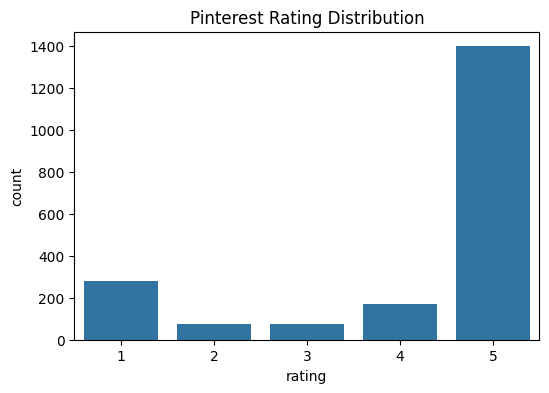

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='rating', data=df)

plt.title("Pinterest Rating Distribution")

plt.show()

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,rating,date,clean_review
0,I love pinterest because it's a great place to...,5,2026-03-07 07:54:22,i love pinterest because its a great place to ...
1,Just like every other single app that used to ...,1,2026-03-07 07:51:18,just like every other single app that used to ...
2,Good,5,2026-03-07 07:46:25,good
3,I can't danload on my xplayer anymore,5,2026-03-07 07:39:26,i cant danload on my xplayer anymore
4,it's very useful,5,2026-03-07 07:28:41,its very useful


In [ ]:
def get_polarity(text):

    analysis = TextBlob(text)

    return analysis.sentiment.polarity

In [ ]:
df['polarity'] = df['clean_review'].apply(get_polarity)

In [ ]:
def sentiment_label(score):

    if score > 0:
        return "Positive"

    elif score == 0:
        return "Neutral"

    else:
        return "Negative"

In [ ]:
df['sentiment'] = df['polarity'].apply(sentiment_label)

df.head()

,review,rating,date,clean_review,polarity,sentiment
0,I love pinterest because it's a great place to...,5,2026-03-07 07:54:22,i love pinterest because its a great place to ...,0.600000,Positive
1,Just like every other single app that used to ...,1,2026-03-07 07:51:18,just like every other single app that used to ...,0.233929,Positive
2,Good,5,2026-03-07 07:46:25,good,0.700000,Positive
3,I can't danload on my xplayer anymore,5,2026-03-07 07:39:26,i cant danload on my xplayer anymore,0.000000,Neutral
4,it's very useful,5,2026-03-07 07:28:41,its very useful,0.390000,Positive


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,1450
Neutral,385
Negative,165


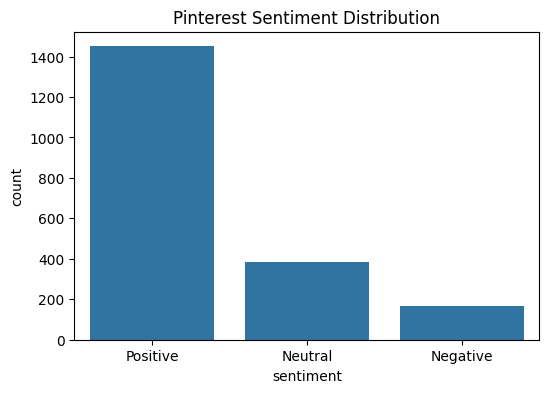

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Pinterest Sentiment Distribution")

plt.show()

In [ ]:
from wordcloud import WordCloud

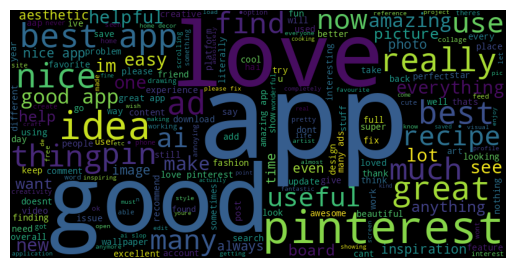

In [ ]:
positive = df[df['sentiment']=="Positive"]

text = " ".join(positive['clean_review'])

wordcloud = WordCloud(width=800,height=400).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [ ]:
df.to_csv("pinterest_sentiment.csv", index=False)

In [ ]:
from google.colab import files
files.download("pinterest_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("pinterest_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("pinterest_reviews.csv")

In [4]:
df['sentiment_rating'] = df['rating'].apply(lambda x: "Positive" if x>=4 else ("Neutral" if x==3 else "Negative"))

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review            2000 non-null   object
 1   rating            2000 non-null   int64 
 2   date              2000 non-null   object
 3   sentiment_rating  2000 non-null   object
dtypes: int64(1), object(3)
memory usage: 62.6+ KB


In [6]:
df.describe()

,rating
count,2000.000000
mean,4.181000
std,1.442317
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [7]:
df.isnull().sum()

,0
review,0
rating,0
date,0
sentiment_rating,0


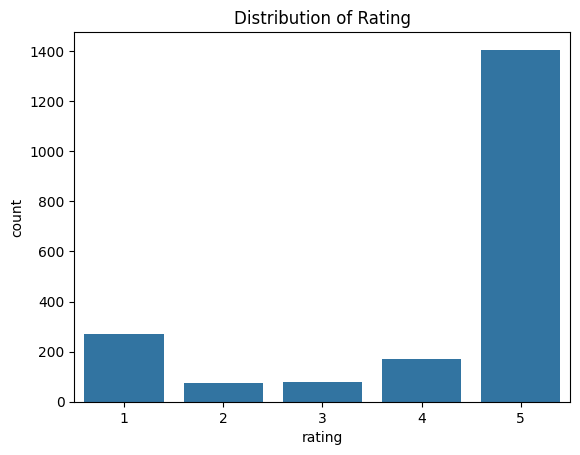

In [8]:
plt.figure()

sns.countplot(x='rating', data=df)

plt.title("Distribution of Rating")

plt.show()

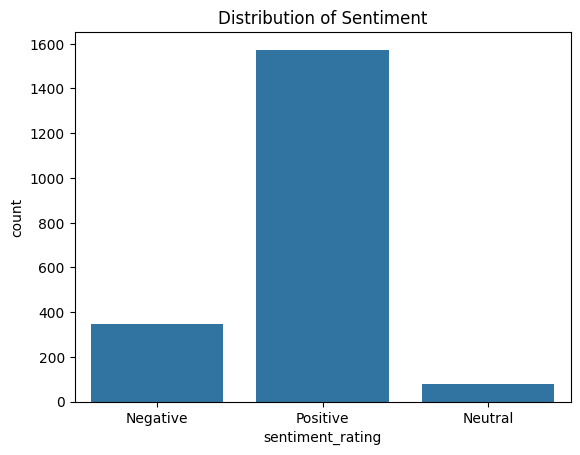

In [9]:
plt.figure()

sns.countplot(x='sentiment_rating', data=df)

plt.title("Distribution of Sentiment")

plt.show()

In [10]:
df['review_length'] = df['review'].astype(str).apply(len)

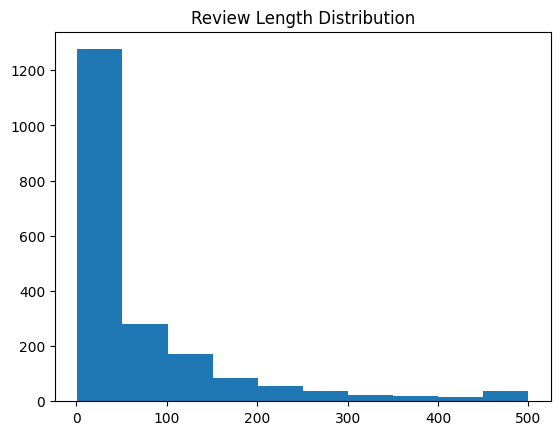

In [11]:
plt.figure()

plt.hist(df['review_length'])

plt.title("Review Length Distribution")

plt.show()

In [12]:
df.groupby('sentiment_rating')['review_length'].mean()

,review_length
sentiment_rating,
Negative,143.705202
Neutral,139.737500
Positive,51.621347


In [13]:
from collections import Counter

all_words = " ".join(df['review'].astype(str)).lower().split()

word_counts = Counter(all_words)

word_counts.most_common(10)

[('i', 938),
 ('and', 805),
 ('the', 719),
 ('app', 675),
 ('to', 622),
 ('it', 599),
 ('is', 478),
 ('this', 460),
 ('a', 384),
 ('for', 379)]

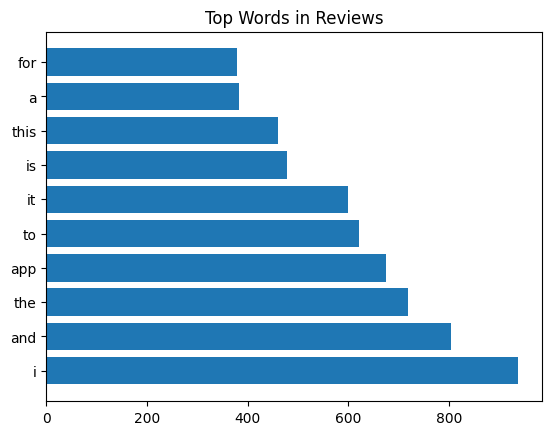

In [14]:
top_words = pd.DataFrame(word_counts.most_common(10), columns=['word','count'])

plt.figure()

plt.barh(top_words['word'], top_words['count'])

plt.title("Top Words in Reviews")

plt.show()